# Assignment 2: Scalability of Support Vector Machines
## Miles Nordwall, Nathan Nail

In [38]:
import numpy as np
from datetime import datetime

In [40]:
NUM_ITER = 100
ETA = 0.01
EPOCHS = 50

#global variable to keep track of runtimes of each model
SVC_IRIS_t = 0.0

### Task #1 Implement LinearSVC

In [43]:
class LinearSVC(object):
    """
    Linear Support Vector Classifier
    Params: 
    eta (float) : Learning rate (between 0.0 and 1.0)
    n_iter (int) : Number of passes over the training dataset.
    random_state (int) : Random number generator seed for random weight initialization.

    Attrs:
    w_ (1d-array) : Weights after fitting with bias absorbed at X[0].
    losses_ (list) : Hinge Loss with L2-regularization loss function values in each epoch.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.rand_gen = []
        self.w_initialized = False

    def fit(self, X, y, C=0.1):
        """
        Learns parameters from the training data
        Uses SGD
        Params:
        X {array-like}, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of examples and n_features is the number of features.
        y (array-like) ,shape = [n_examples]
        Target values.
        C {float} = regularization hyperparameter 

        Returns:
        self : Instance of LinearSVC
        """
        self.losses_ = []
        X = self._initialize_weights(X,X.shape[1])
        c_n = C /X.shape[0]
        
        for _ in range(self.n_iter):
            
            X, y = self._shuffle(X, y)
            epoch_losses = []
            
            for xi, yi in zip(X, y):
                
                y_hat = self.net_input(xi)
                fn_margin = 1 - (yi*y_hat)
                Li = np.maximum(0,fn_margin)

                #gd = self.w_ + c_n * (-yi*xi) #dL/dw
                b_update = 0
                if fn_margin > 0: #case 1
                    gd = self.w_ + c_n * (-yi*xi) #dL/dw
                    b_update = -yi
                else: #case 2
                    gd = self.w_
                epoch_losses.append(Li)
                self.w_ += self.eta* (-gd)
                self.b_ += self.eta* b_update
            avg_loss = np.mean(epoch_losses)
            self.losses_.append(avg_loss)
        return self
        

    
    def _initialize_weights(self, X, m):
        """Initialize weights to small random numbers
        """
        self.b_ = np.float_(0.)
        self.rand_gen = np.random.RandomState(self.random_state)
        self.w_ = self.rand_gen.normal(loc=0.0, scale=0.01,
                                  size=m)
        self.w_initialized = True
        return X
        

    def _update_weights(self, xi, y):
        """Calculate hinge loss then apply GD to L wrt w_"""
        y_hat = self.net_input(xi)
        Li = np.max(0, 1 - (y*y_hat))
        loss = c_n * (Li + (0.5 * (self.w_.shape[0])^2))
        self.w_ += self.w_ + self.eta - loss
        self.b_ += gd
        return loss
        
    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rand_gen.permutation(len(y))
        return X[r], y[r]

    def net_input(self, X): #TODO1 the net_input for svc is w^Tx-b right? unabsorb b?
        """Calculate net input"""
        return np.dot(X, self.w_) - self.b_

    def predict(self, X):
        """Return class label after unit step"""
        return np.sign(self.net_input(X))
    
        

### Task #2 make_classification function
$$\bar{a}^T \bar{x} = b$$
$$\{ \bar{x} \in \mathbb{R}^d | \bar{a}^T \bar{x} = b\}$$
$$\text{where } b=0$$

In [46]:
def make_classification(d,n, u=100,seed=1):
    """
    Generates a set of linearly seperable data
    based on a random seperation hyperplane
    d (int) : dimension of set of points
    """
    rand_gen = np.random.RandomState(seed)
    #generate random vector a s.t ||a||=d
    a = rand_gen.random(size=d) #TODO values are between [0-1] btw, is that okay?
    
    #randomly select n samples in range of [-u,u] in each dimension using a gaussian
    
    X = rand_gen.normal(scale=u,size=(n,d))    
    
    #give each xi a label yi 
    y = []
    for j in range(n):
        if a.T.dot(X[j]) < 0: #is this correct?
            yi = -1
        else:
            yi = 1
        y.append(yi)
    Y = np.array(y)

    #TODO make the first 70% training, and the last 30% test
    return X,Y

In [48]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
def plot_decision_regions(X, y, classifier, test_idx=None,
                          resolution=0.02):
    #taken from textbook
    # setup marker generator and color map
    markers = ('o', 'x', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='Test set')

/var/folders/q8/dkdmw0695vz4xd77f20xf2h00000gp/T/ipykernel_2449/127553513.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


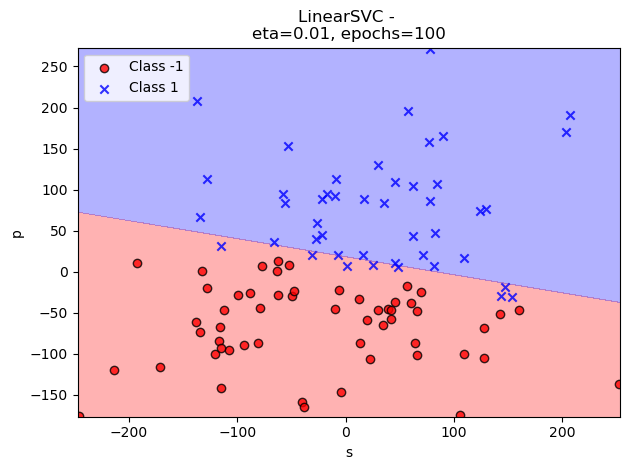

In [50]:
#plotting the decision boundary found for linear svc on the Iris dataset
svc = LinearSVC(n_iter=100, eta=0.001)
X,Y = make_classification(d=2,n=100,u=100,seed=96)


svc_start = datetime.now()
svc.fit(X, Y)
svc_end = datetime.now()
SVC_t = (svc_end - svc_start).total_seconds() *1000

plot_decision_regions(X, Y, classifier=svc)
plt.title(f'LinearSVC - \n'
          f'eta={ETA}, epochs={NUM_ITER}')
plt.xlabel('s')
plt.ylabel('p')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

   Epochs  Dim  Samples       Time  Loss Convergence
0      50   10      500   0.182308          1.049825
1      50   10     5000   1.676600          0.232353
2      50   10    50000  16.898024          0.022556
3      50   50      500   0.170592          1.812536
4      50   50     5000   1.729486          0.316935
5      50   50    50000  17.232860          0.034588
6      50  100      500   0.172701          2.199961
7      50  100     5000   1.769121          0.451004
8      50  100    50000  17.635847          0.044727


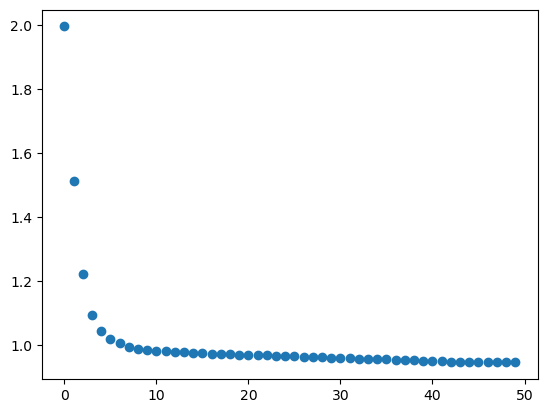

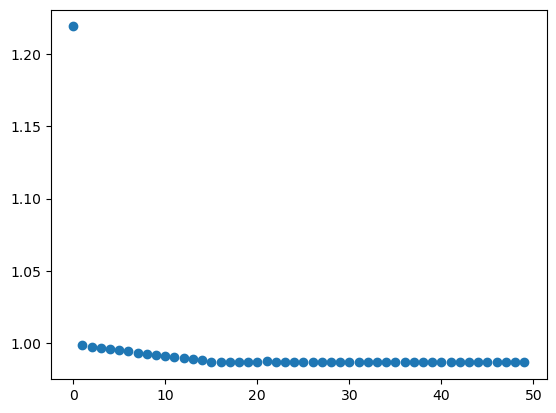

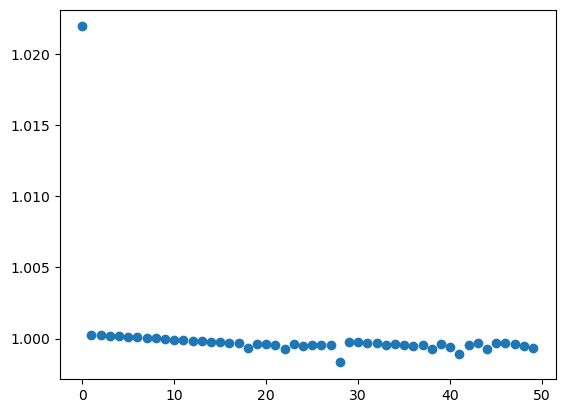

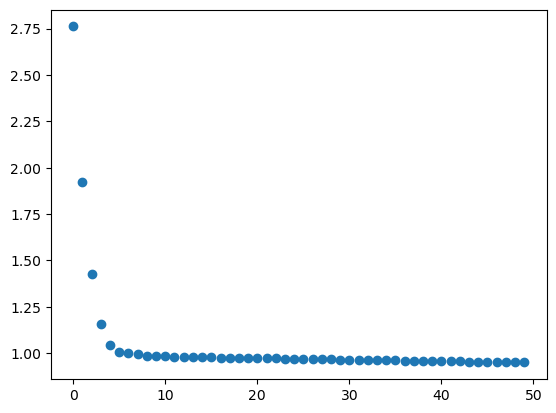

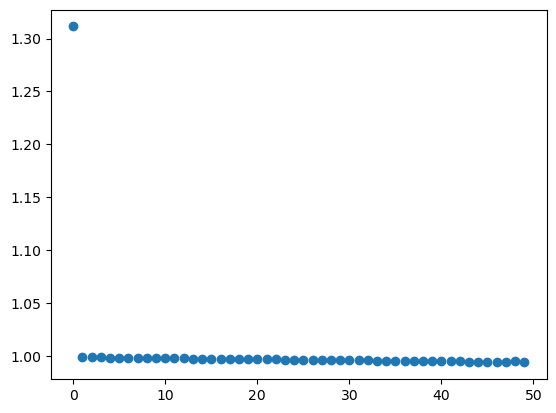

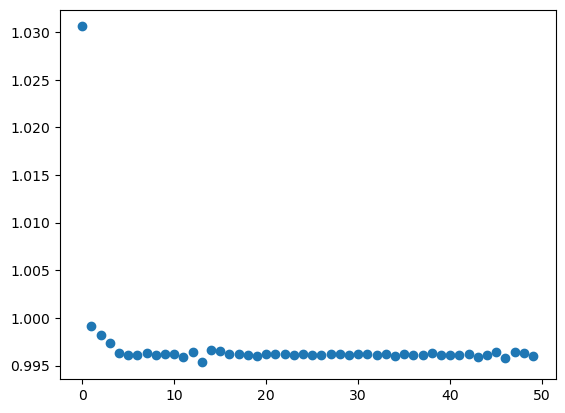

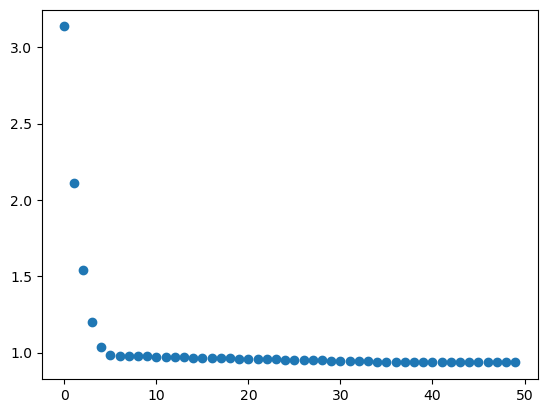

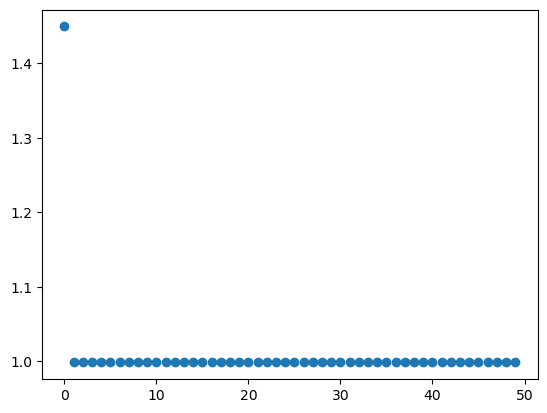

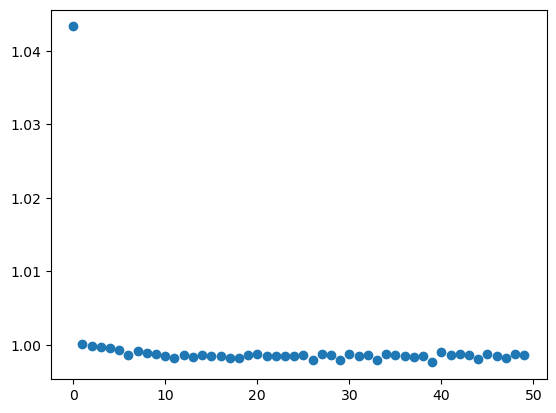

In [54]:
#from LinearSVC import LinearSVC as mySVC
#from sklearn.svm import LinearSVC as skSVC
import time
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt 

"""
Investigate the scalability of the LinearSVC class you have implemented. Using the dataset
generator developed in the previous task, you may produce random datasets regarding to the 9 combinations
of the following scales: d = 10, 50, 100 and n = 500, 5000, 50000. You may assign a large constant such
as 100 to u. (Please feel free to slightly adjust the scales according to your computer’s hardware.) Evaluate
the time cost and loss convergence of your linear SVC on the 9 datasets. The comparison should be given
by tables along with explanations.
"""

import itertools

n_dims = [10, 50, 100]
n_samples = [500, 5000, 50000]

sets = []
errors = []

headers = ["Epochs","Dim","Samples","Time","Loss Convergence"]
d_s = []
svc1 = LinearSVC(n_iter=50, eta=0.001)

def plot_losses(loss_values : list):
    x_vals = np.linspace(0, 49, 50)
    plot = plt.plot()
    plt.scatter(x = x_vals, y = loss_values)
    plt.show()

for dims, samples in itertools.product(n_dims, n_samples):
    X,Y = make_classification(d=dims,n=samples,u=100,seed=96)
    #svc1.fit(X, Y)
    fit_start = time.clock_gettime(5)
    svc1.fit(X, Y, 0.001)
    fit_end = time.clock_gettime(5)
    #print("%d dims, %d samples: %f" % (dims, samples, fit_end - fit_start))
    
    end_weight = svc1.w_
    errors.append(svc1.losses_)

    d_s.append([EPOCHS, dims, samples, fit_end - fit_start, svc1.losses_[0] - svc1.losses_[-1]])  #drop in loss from first to last sample
    
np.set_printoptions(suppress=True, precision=4)
table = pd.DataFrame(d_s, columns=headers)
print(table)

for l in errors:
    plot_losses(l)